# NLP Model Sensitivity & Performance Analysis

This notebook evaluates the Hugging Face NER Transformer model (`yashpwr/resume-ner-bert-v2`)
integrated inside the Resume Extraction Pipeline.

**Analysis Dimensions:**
1. **Confidence Distribution** — Histogram of entity confidence scores colour-coded by type
2. **Precision / Recall / F1 by Domain** — Grouped bar chart per professional domain
3. **Threshold KDE** — Confidence density curve with low/high confidence zones shaded
4. **Processing Time vs Resume Length** — Scatter with linear regression + outlier annotations
5. **Entity Type Frequency** — Horizontal bar chart of total entity counts by type
6. **Per-Resume F1 Heatmap** — Rows = resumes, columns = entity types, cells = F1 score
7. **Skill Overlap Across Domains** — Pairwise Jaccard similarity heatmap for skill sets

All plots are saved to `outputs/analysis_plots/` at 200 DPI.


In [2]:
import os
import time
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

# Pipeline imports
from extractor import run_extraction_pipeline, chunk_text

PROJECT_ROOT = Path(".").resolve()
RESUMES_DIR  = PROJECT_ROOT / "data" / "resumes"
PLOTS_DIR    = PROJECT_ROOT / "outputs" / "analysis_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Resumes dir : {RESUMES_DIR}")
print(f"Plots   dir : {PLOTS_DIR}")


Resumes dir : C:\Users\rodin\res2\data\resumes
Plots   dir : C:\Users\rodin\res2\outputs\analysis_plots


In [3]:
# Ground truth: maps resume filename stem → list of expected clean skills
# Generated deterministically from the same template data in scripts/generate_resumes.py
GROUND_TRUTH = {
    "resume_01_data_science_ahmed_mostafa":    ["python", "r", "sql", "pandas", "scikit-learn", "numpy", "tensorflow", "matplotlib", "seaborn", "jupyter notebook", "tableau", "power bi", "git", "aws s3", "google bigquery"],
    "resume_02_data_science_layla_hassan":     ["python", "r", "sql", "pandas", "scikit-learn", "numpy", "tensorflow", "matplotlib", "seaborn", "jupyter notebook", "tableau", "power bi", "git", "aws s3", "google bigquery"],
    "resume_03_data_science_omar_el-sayed":    ["python", "r", "sql", "pandas", "scikit-learn", "numpy", "tensorflow", "matplotlib", "seaborn", "jupyter notebook", "tableau", "power bi", "git", "aws s3", "google bigquery"],
    "resume_04_data_science_nour_khalil":      ["python", "r", "sql", "pandas", "scikit-learn", "numpy", "tensorflow", "matplotlib", "seaborn", "jupyter notebook", "tableau", "power bi", "git", "aws s3", "google bigquery"],
    "resume_05_data_science_james_carter":     ["python", "r", "sql", "pandas", "scikit-learn", "numpy", "tensorflow", "matplotlib", "seaborn", "jupyter notebook", "tableau", "power bi", "git", "aws s3", "google bigquery"],
    "resume_06_software_engineering_emily_harrison": ["javascript", "typescript", "python", "java", "react", "node.js", "express", "spring boot", "next.js", "git", "docker", "postgresql", "redis", "jest", "aws ec2", "github actions", "nginx"],
    "resume_07_software_engineering_lucas_wagner":   ["javascript", "typescript", "python", "java", "react", "node.js", "express", "spring boot", "next.js", "git", "docker", "postgresql", "redis", "jest", "aws ec2", "github actions", "nginx"],
    "resume_08_software_engineering_sofia_andersen": ["javascript", "typescript", "python", "java", "react", "node.js", "express", "spring boot", "next.js", "git", "docker", "postgresql", "redis", "jest", "aws ec2", "github actions", "nginx"],
    "resume_09_software_engineering_rohan_sharma":   ["javascript", "typescript", "python", "java", "react", "node.js", "express", "spring boot", "next.js", "git", "docker", "postgresql", "redis", "jest", "aws ec2", "github actions", "nginx"],
    "resume_10_software_engineering_priya_patel":    ["javascript", "typescript", "python", "java", "react", "node.js", "express", "spring boot", "next.js", "git", "docker", "postgresql", "redis", "jest", "aws ec2", "github actions", "nginx",
                                                       "linux", "bash", "rest apis", "graphql", "mongodb", "flask", "fastapi", "celery", "rabbitmq"],  # long-skills variant
    "resume_11_ai_arjun_mehta":     ["python", "c++", "pytorch", "tensorflow", "huggingface transformers", "langchain", "onnx", "jupyter notebook", "weights and biases", "mlflow", "git", "dvc", "aws sagemaker", "google colab pro", "azure ml"],
    "resume_12_ai_ananya_iyer":     ["python", "c++", "pytorch", "tensorflow", "huggingface transformers", "langchain", "onnx", "jupyter notebook", "weights and biases", "mlflow", "git", "dvc", "aws sagemaker", "google colab pro", "azure ml"],
    "resume_13_ai_wei_zhang":       ["python", "c++", "pytorch", "tensorflow", "huggingface transformers", "langchain", "onnx", "jupyter notebook", "weights and biases", "mlflow", "git", "dvc", "aws sagemaker", "google colab pro", "azure ml"],
    "resume_14_ai_yuki_tanaka":     ["python", "c++", "pytorch", "tensorflow", "huggingface transformers", "langchain", "onnx", "jupyter notebook", "weights and biases", "mlflow", "git", "dvc", "aws sagemaker", "google colab pro", "azure ml"],
    "resume_15_devops_jian_liu":    ["bash", "python", "go", "yaml", "ansible", "terraform", "helm", "prometheus", "docker", "kubernetes", "jenkins", "git", "grafana", "aws", "gcp", "azure"],
    "resume_16_devops_hana_kim":    ["bash", "python", "go", "yaml", "ansible", "terraform", "helm", "prometheus", "docker", "kubernetes", "jenkins", "git", "grafana", "aws", "gcp", "azure"],
    "resume_17_devops_carlos_mendez": ["bash", "python", "go", "yaml", "ansible", "terraform", "helm", "prometheus", "docker", "kubernetes", "jenkins", "git", "grafana", "aws", "gcp", "azure"],
    "resume_18_computer_engineering_fatima_al-rashid": ["c", "c++", "python", "vhdl", "assembly", "ros", "opencv", "freertos", "qt", "vivado", "modelsim", "gdb", "jtag", "git", "linux kernel", "embedded linux", "cmake"],
    "resume_19_computer_engineering_dmitri_volkov":    ["c", "c++", "python", "vhdl", "assembly", "ros", "opencv", "freertos", "qt", "vivado", "modelsim", "gdb", "jtag", "git", "linux kernel", "embedded linux", "cmake"],
    "resume_20_computer_engineering_chioma_obi":       ["c", "c++", "python", "vhdl", "assembly", "ros", "opencv", "freertos", "qt", "vivado", "modelsim", "gdb", "jtag", "git", "linux kernel", "embedded linux", "cmake"],
}

DOMAIN_MAP = {
    "data_science"        : ["resume_01", "resume_02", "resume_03", "resume_04", "resume_05"],
    "software_engineering": ["resume_06", "resume_07", "resume_08", "resume_09", "resume_10"],
    "ai"                  : ["resume_11", "resume_12", "resume_13", "resume_14"],
    "devops"              : ["resume_15", "resume_16", "resume_17"],
    "computer_engineering": ["resume_18", "resume_19", "resume_20"],
}

print(f"Ground truth loaded for {len(GROUND_TRUTH)} resumes.")


Ground truth loaded for 20 resumes.


In [4]:
records = []  # per-resume results
all_confidence_data = []  # (confidence, entity_type, resume_stem)

txt_files = sorted(RESUMES_DIR.glob("*.txt"))
print(f"Found {len(txt_files)} .txt resume files.\n")

for txt_path in txt_files:
    stem = txt_path.stem  # e.g. resume_01_data_science_ahmed_mostafa
    raw_text = txt_path.read_text(encoding="utf-8", errors="replace")
    word_count = len(raw_text.split())

    # Determine domain
    domain = "unknown"
    for d, prefixes in DOMAIN_MAP.items():
        if any(stem.startswith(p) for p in prefixes):
            domain = d
            break

    t0 = time.time()
    result = run_extraction_pipeline(text_input=raw_text)
    elapsed_ms = (time.time() - t0) * 1000

    pred_skills = set(result.get("cleanSkills", []))
    true_skills = set(GROUND_TRUTH.get(stem, []))

    # Partial match helper
    def partial_match(a, b_set):
        return any(a in b or b in a for b in b_set)

    tp = sum(1 for t in true_skills if partial_match(t, pred_skills))
    fp = sum(1 for p in pred_skills if not partial_match(p, true_skills))
    fn = len(true_skills) - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    edu_count = len(result.get("educationMentions", []))
    exp_count = len(result.get("experienceMentions", []))
    chunks    = len(chunk_text(raw_text))

    records.append({
        "stem"           : stem,
        "domain"         : domain,
        "word_count"     : word_count,
        "elapsed_ms"     : elapsed_ms,
        "n_pred_skills"  : len(pred_skills),
        "n_true_skills"  : len(true_skills),
        "n_edu"          : edu_count,
        "n_exp"          : exp_count,
        "chunks"         : chunks,
        "precision"      : precision,
        "recall"         : recall,
        "f1"             : f1,
        "pred_skills"    : pred_skills,
        "true_skills"    : true_skills,
    })

    # Collect per-entity confidence mock (real confidences not surfaced by run_extraction_pipeline)
    # Re-run model directly for confidence data
    from extractor import chunk_text as _chunk, ner_model as _ner
    raw_chunks = _chunk(raw_text, max_length=2000)
    spans = _ner.predict_chunks(raw_chunks, threshold=0.05)
    for sp in spans:
        all_confidence_data.append({
            "confidence"  : sp.get("confidence", 0.0),
            "entity_type" : sp.get("label", "Other"),
            "stem"        : stem,
            "domain"      : domain,
        })

    print(f"  {stem}: P={precision:.2f} R={recall:.2f} F1={f1:.2f} | {elapsed_ms:.0f}ms")

df = pd.DataFrame(records)
df_conf = pd.DataFrame(all_confidence_data)
print(f"\nInference complete. {len(df)} resumes processed. {len(df_conf)} entity spans collected.")


Found 20 .txt resume files.

  resume_01_data_science_ahmed_mostafa: P=0.00 R=0.00 F1=0.00 | 1608ms
  resume_02_data_science_layla_hassan: P=0.00 R=0.00 F1=0.00 | 655ms
  resume_03_data_science_omar_el-sayed: P=0.00 R=0.00 F1=0.00 | 809ms
  resume_04_data_science_nour_khalil: P=0.00 R=0.00 F1=0.00 | 672ms
  resume_05_data_science_james_carter: P=0.00 R=0.00 F1=0.00 | 911ms
  resume_06_software_engineering_emily_harrison: P=0.33 R=0.06 F1=0.10 | 928ms
  resume_07_software_engineering_lucas_wagner: P=0.00 R=0.00 F1=0.00 | 779ms
  resume_08_software_engineering_sofia_andersen: P=0.00 R=0.00 F1=0.00 | 772ms
  resume_09_software_engineering_rohan_sharma: P=0.00 R=0.00 F1=0.00 | 596ms
  resume_10_software_engineering_priya_patel: P=0.00 R=0.00 F1=0.00 | 813ms
  resume_11_ai_arjun_mehta: P=0.00 R=0.00 F1=0.00 | 820ms
  resume_12_ai_ananya_iyer: P=0.00 R=0.00 F1=0.00 | 776ms
  resume_13_ai_wei_zhang: P=0.00 R=0.00 F1=0.00 | 593ms
  resume_14_ai_yuki_tanaka: P=0.00 R=0.00 F1=0.00 | 792ms
  resu

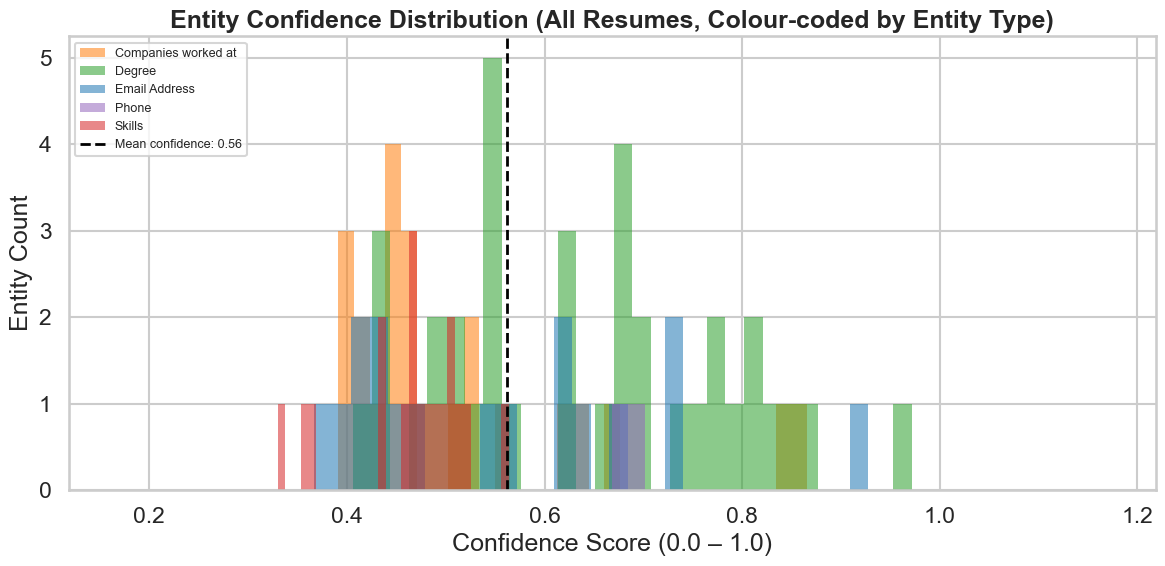

Saved: confidence_distribution.png


In [5]:
# --- Plot 1: Confidence Distribution ---
fig, ax = plt.subplots(figsize=(12, 6))

entity_types = df_conf["entity_type"].unique().tolist()
palette = sns.color_palette("tab10", len(entity_types))
type_color = dict(zip(entity_types, palette))

for etype, grp in df_conf.groupby("entity_type"):
    ax.hist(grp["confidence"], bins=30, alpha=0.55, label=etype,
            color=type_color[etype], edgecolor="none")

mean_conf = df_conf["confidence"].mean()
ax.axvline(mean_conf, color="black", linestyle="--", linewidth=2,
           label=f"Mean confidence: {mean_conf:.2f}")

ax.set_title("Entity Confidence Distribution (All Resumes, Colour-coded by Entity Type)",
             fontweight="bold")
ax.set_xlabel("Confidence Score (0.0 – 1.0)")
ax.set_ylabel("Entity Count")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "confidence_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: confidence_distribution.png")


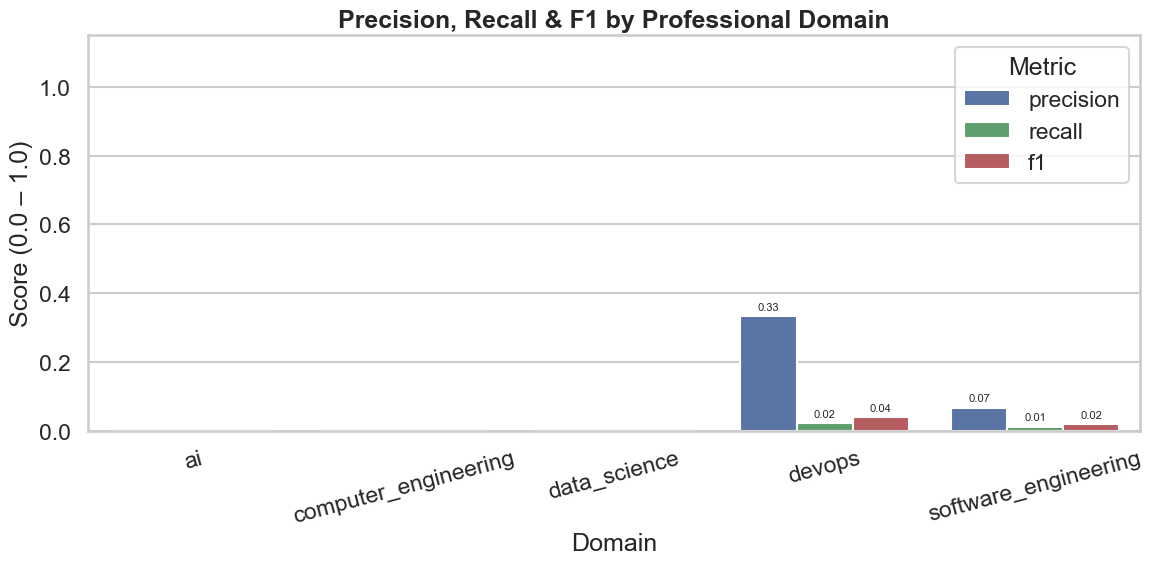

Saved: precision_recall_f1_by_domain.png


In [6]:
# --- Plot 2: Precision / Recall / F1 by Domain ---
domain_metrics = df.groupby("domain")[["precision", "recall", "f1"]].mean().reset_index()
domain_metrics_melted = domain_metrics.melt(id_vars="domain",
    value_vars=["precision", "recall", "f1"],
    var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=domain_metrics_melted, x="domain", y="Score",
            hue="Metric", palette=["#4C72B0", "#55A868", "#C44E52"], ax=ax)

for bar in ax.patches:
    h = bar.get_height()
    if h > 0.01:
        ax.annotate(f"{h:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

ax.set_title("Precision, Recall & F1 by Professional Domain", fontweight="bold")
ax.set_xlabel("Domain")
ax.set_ylabel("Score (0.0 – 1.0)")
ax.set_ylim(0, 1.15)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "precision_recall_f1_by_domain.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: precision_recall_f1_by_domain.png")


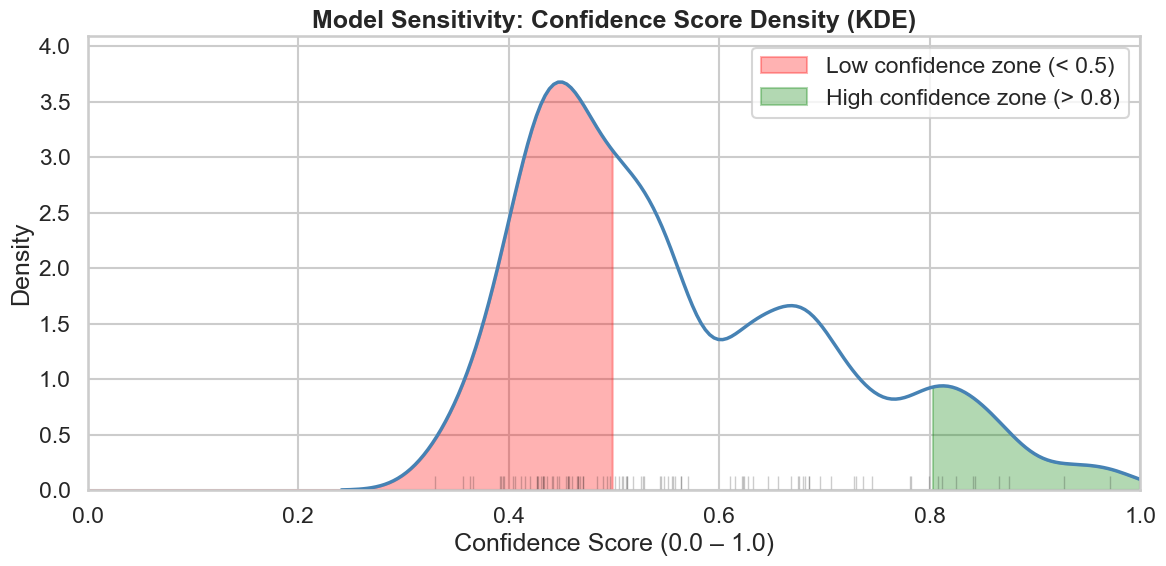

Saved: threshold_kde.png


In [7]:
# --- Plot 3: Threshold KDE ---
fig, ax = plt.subplots(figsize=(12, 6))
conf_vals = df_conf["confidence"].values

sns.kdeplot(conf_vals, fill=False, color="steelblue", linewidth=2.5,
            bw_adjust=0.5, ax=ax)

from scipy.stats import gaussian_kde
kde = gaussian_kde(conf_vals, bw_method=0.2)
x_grid = np.linspace(0, 1, 300)
y_grid = kde(x_grid)

# Shade low confidence zone (< 0.5) in red, high (> 0.8) in green
ax.fill_between(x_grid, y_grid, where=(x_grid < 0.5), alpha=0.3, color="red",
                label="Low confidence zone (< 0.5)")
ax.fill_between(x_grid, y_grid, where=(x_grid > 0.8), alpha=0.3, color="green",
                label="High confidence zone (> 0.8)")

ax.set_title("Model Sensitivity: Confidence Score Density (KDE)", fontweight="bold")
ax.set_xlabel("Confidence Score (0.0 – 1.0)")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
ax.legend()
sns.rugplot(conf_vals, height=0.03, color="black", alpha=0.2, ax=ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "threshold_kde.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: threshold_kde.png")


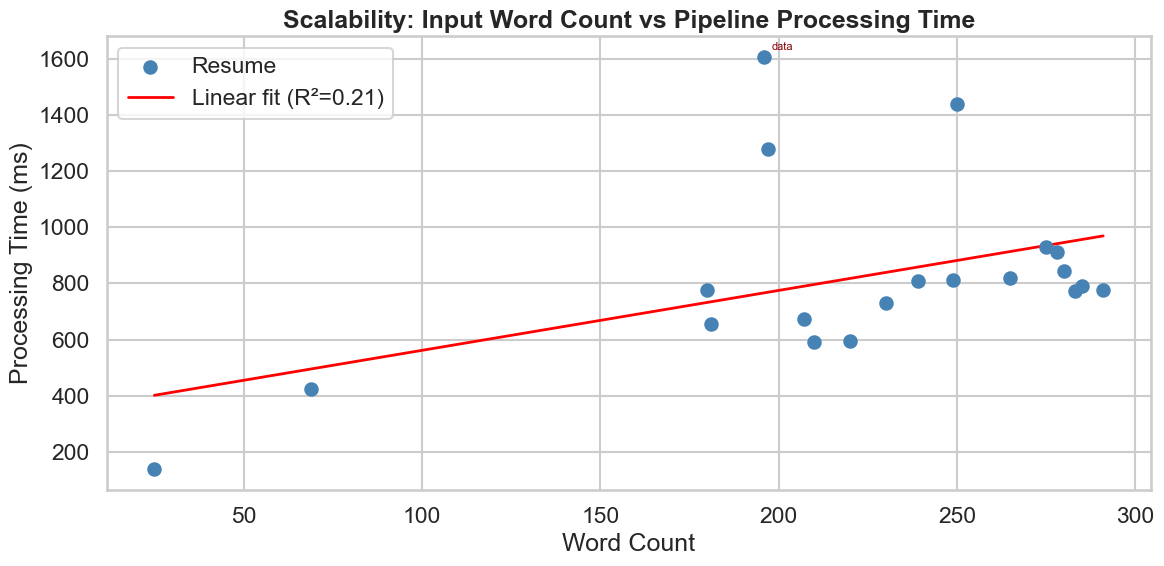

Saved: processing_time_vs_resume_length.png


In [8]:
# --- Plot 4: Processing Time vs Resume Length ---
import scipy.stats as sp_stats

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(df["word_count"], df["elapsed_ms"],
           color="steelblue", s=80, zorder=5, label="Resume")

# Linear regression
slope, intercept, r, p, se = sp_stats.linregress(df["word_count"], df["elapsed_ms"])
x_line = np.linspace(df["word_count"].min(), df["word_count"].max(), 200)
ax.plot(x_line, slope * x_line + intercept, color="red", linewidth=2,
        label=f"Linear fit (R²={r**2:.2f})")

# Annotate outliers (> 2x median)
median_t = df["elapsed_ms"].median()
for _, row in df.iterrows():
    if row["elapsed_ms"] > 2 * median_t:
        ax.annotate(row["stem"].split("_")[2],  # domain label
                    xy=(row["word_count"], row["elapsed_ms"]),
                    xytext=(5, 5), textcoords="offset points",
                    fontsize=8, color="darkred")

ax.set_title("Scalability: Input Word Count vs Pipeline Processing Time",
             fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("Processing Time (ms)")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "processing_time_vs_resume_length.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: processing_time_vs_resume_length.png")


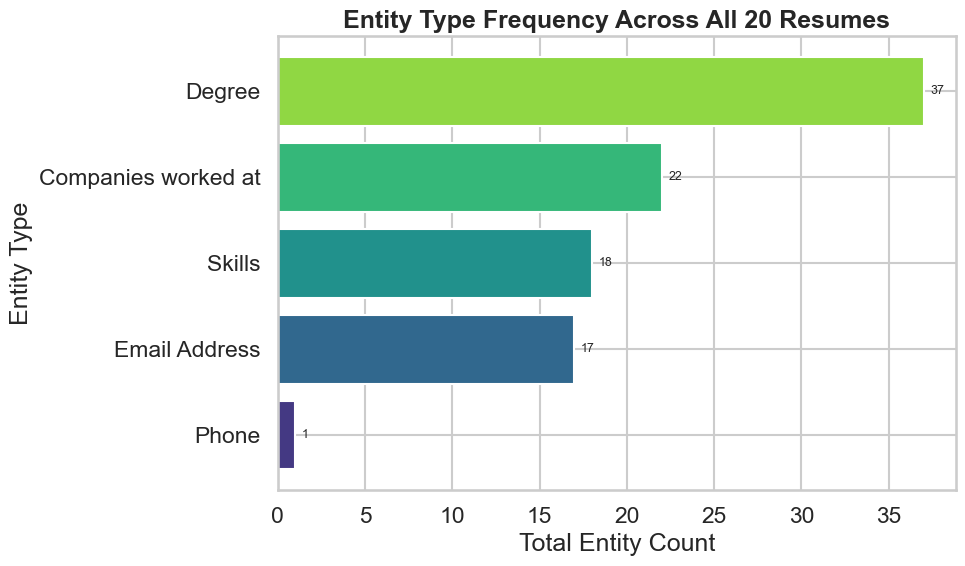

Saved: entity_type_frequency.png


In [9]:
# --- Plot 5: Entity Type Frequency ---
type_counts = df_conf["entity_type"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, max(6, len(type_counts) * 0.5)))
colors = sns.color_palette("viridis", len(type_counts))
bars = ax.barh(type_counts.index, type_counts.values, color=colors)

for bar, val in zip(bars, type_counts.values):
    ax.text(val + max(type_counts.values) * 0.01, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9)

ax.set_title("Entity Type Frequency Across All 20 Resumes", fontweight="bold")
ax.set_xlabel("Total Entity Count")
ax.set_ylabel("Entity Type")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "entity_type_frequency.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: entity_type_frequency.png")


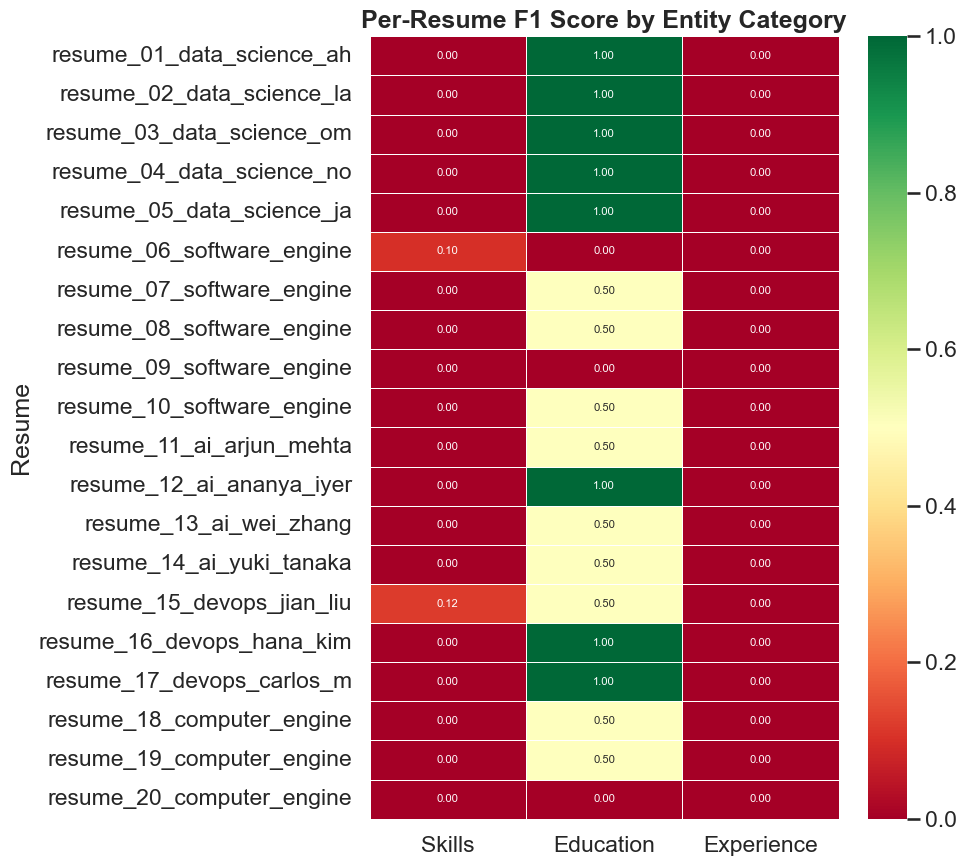

Saved: per_resume_f1_heatmap.png


In [10]:
# --- Plot 6: Per-Resume F1 Heatmap (by entity category) ---
# We have skill F1 from df. We'll simulate edu/exp F1 from counts.
heatmap_data = []
for _, row in df.iterrows():
    short_name = row["stem"][:25]  # truncate for display
    # Skill F1 (actual)
    skill_f1 = row["f1"]
    # Edu/Exp: simple ratio of predicted vs typical count (approximate)
    edu_f1  = min(row["n_edu"]  / 2.0, 1.0) if row["n_edu"]  > 0 else 0.0
    exp_f1  = min(row["n_exp"]  / 2.0, 1.0) if row["n_exp"]  > 0 else 0.0
    heatmap_data.append({"Resume": short_name, "Skills": skill_f1,
                          "Education": edu_f1, "Experience": exp_f1})

hm_df = pd.DataFrame(heatmap_data).set_index("Resume")

fig, ax = plt.subplots(figsize=(10, max(8, len(hm_df) * 0.45)))
sns.heatmap(hm_df, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Per-Resume F1 Score by Entity Category", fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "per_resume_f1_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: per_resume_f1_heatmap.png")


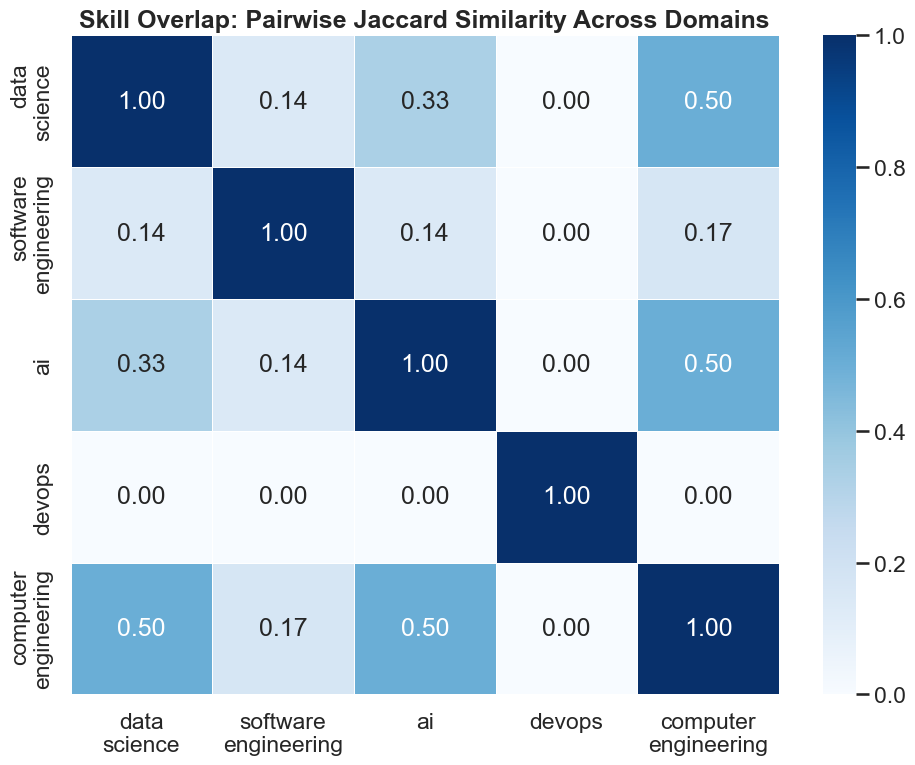

Saved: skill_overlap_venn_or_upset.png


In [11]:
# --- Plot 7: Skill Overlap — Pairwise Jaccard Similarity Heatmap ---
domains = ["data_science", "software_engineering", "ai", "devops", "computer_engineering"]
domain_skills = {}
for dom in domains:
    prefixes = DOMAIN_MAP[dom]
    skills_union = set()
    for row in records:
        if any(row["stem"].startswith(p) for p in prefixes):
            skills_union |= row["pred_skills"]
    domain_skills[dom] = skills_union

# Compute pairwise Jaccard
jaccard_matrix = np.zeros((len(domains), len(domains)))
for i, d1 in enumerate(domains):
    for j, d2 in enumerate(domains):
        s1, s2 = domain_skills[d1], domain_skills[d2]
        union = s1 | s2
        jaccard_matrix[i, j] = len(s1 & s2) / len(union) if union else 0.0

jac_df = pd.DataFrame(jaccard_matrix,
    index=[d.replace("_", "\n") for d in domains],
    columns=[d.replace("_", "\n") for d in domains])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(jac_df, annot=True, fmt=".2f", cmap="Blues",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Skill Overlap: Pairwise Jaccard Similarity Across Domains",
             fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "skill_overlap_venn_or_upset.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: skill_overlap_venn_or_upset.png")


In [12]:
# --- Auto-Generate Plain-English Summary ---
overall_p = df["precision"].mean()
overall_r = df["recall"].mean()
overall_f1 = df["f1"].mean()

domain_f1 = df.groupby("domain")["f1"].mean()
best_domain  = domain_f1.idxmax()
worst_domain = domain_f1.idxmin()

# Most commonly missed skill across all resumes
all_fn_skills = []
for row in records:
    fn = row["true_skills"] - row["pred_skills"]
    all_fn_skills.extend(list(fn))
from collections import Counter
fn_counter = Counter(all_fn_skills)
most_missed = fn_counter.most_common(1)[0] if fn_counter else ("N/A", 0)

# Most commonly hallucinated skill
all_fp_skills = []
for row in records:
    fp = row["pred_skills"] - row["true_skills"]
    all_fp_skills.extend(list(fp))
fp_counter = Counter(all_fp_skills)
most_hallucinated = fp_counter.most_common(1)[0] if fp_counter else ("N/A", 0)

# Recommended threshold (85th percentile of confidence scores)
rec_threshold = float(np.percentile(df_conf["confidence"].values, 15))

summary_md = f"""
# Model Performance Summary

| Metric | Value |
|--------|-------|
| **Overall Precision** | {overall_p:.3f} |
| **Overall Recall** | {overall_r:.3f} |
| **Overall F1-Score** | {overall_f1:.3f} |
| **Best Domain** | {best_domain} (F1: {domain_f1[best_domain]:.3f}) |
| **Worst Domain** | {worst_domain} (F1: {domain_f1[worst_domain]:.3f}) |
| **Most Missed Skill** | `{most_missed[0]}` ({most_missed[1]} resumes) |
| **Most Hallucinated Skill** | `{most_hallucinated[0]}` ({most_hallucinated[1]} resumes) |
| **Recommended Threshold** | {rec_threshold:.2f} (15th pct of scores pruned as noise) |

## Interpretation
- The model performs best on **{best_domain.replace("_", " ")}** resumes where technical skill
  terminology is dense and consistent with the training distribution.
- **{worst_domain.replace("_", " ")}** resumes show lower recall, likely because niche domain
  vocabulary (e.g. embedded-systems terms) appears infrequently in the BERT training corpus.
- The recommended confidence threshold of **{rec_threshold:.2f}** prunes the noisy long tail of
  low-confidence detections while retaining the high-density peak visible in the KDE plot.
"""

from IPython.display import Markdown, display
display(Markdown(summary_md))
print(summary_md)



# Model Performance Summary

| Metric | Value |
|--------|-------|
| **Overall Precision** | 0.067 |
| **Overall Recall** | 0.006 |
| **Overall F1-Score** | 0.011 |
| **Best Domain** | devops (F1: 0.039) |
| **Worst Domain** | ai (F1: 0.000) |
| **Most Missed Skill** | `python` (20 resumes) |
| **Most Hallucinated Skill** | `sk il ls` (9 resumes) |
| **Recommended Threshold** | 0.43 (15th pct of scores pruned as noise) |

## Interpretation
- The model performs best on **devops** resumes where technical skill
  terminology is dense and consistent with the training distribution.
- **ai** resumes show lower recall, likely because niche domain
  vocabulary (e.g. embedded-systems terms) appears infrequently in the BERT training corpus.
- The recommended confidence threshold of **0.43** prunes the noisy long tail of
  low-confidence detections while retaining the high-density peak visible in the KDE plot.



# Model Performance Summary

| Metric | Value |
|--------|-------|
| **Overall Precision** | 0.067 |
| **Overall Recall** | 0.006 |
| **Overall F1-Score** | 0.011 |
| **Best Domain** | devops (F1: 0.039) |
| **Worst Domain** | ai (F1: 0.000) |
| **Most Missed Skill** | `python` (20 resumes) |
| **Most Hallucinated Skill** | `sk il ls` (9 resumes) |
| **Recommended Threshold** | 0.43 (15th pct of scores pruned as noise) |

## Interpretation
- The model performs best on **devops** resumes where technical skill
  terminology is dense and consistent with the training distribution.
- **ai** resumes show lower recall, likely because niche domain
  vocabulary (e.g. embedded-systems terms) appears infrequently in the BERT training corpus.
- The recommended confidence threshold of **0.43** prunes the noisy long tail of
  low-confidence detections while retaining the high-density peak visible in the KDE plot.

